# Model 2 — XGBoost Multi-Class Classifier
Classes: 1=DDoS, 2=PortScan, 3=BruteForce, 4=General Outlier

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.preprocessing import LabelEncoder

SEED = 42
DATASET_PATH = "../DATASET"
MODEL_PATH   = "../MODELS"

import os
os.makedirs(MODEL_PATH, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load Data

In [2]:
train_df = pd.read_csv(f"{DATASET_PATH}/stage2_train_resampled.csv")
val_df   = pd.read_csv(f"{DATASET_PATH}/stage2_val_clean.csv")
test_df  = pd.read_csv(f"{DATASET_PATH}/stage2_test_clean.csv")

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
print("\nTrain label dist:")
print(train_df['Label'].value_counts())

Train: (1042512, 79), Val: (38321, 79), Test: (42588, 79)

Train label dist:
Label
1    260628
2    260628
3    260628
4    260628
Name: count, dtype: int64


## 2. Split Features / Labels

XGBoost requires labels in range [0, num_classes-1], so we remap 1-4 → 0-3.

In [3]:
LABEL_NAMES = {0: 'DDoS', 1: 'PortScan', 2: 'BruteForce', 3: 'General'}

def split_xy(df):
    X = df.drop(columns=['Label'])
    y = df['Label'] - 1   # remap 1-4 → 0-3
    return X, y

X_train, y_train = split_xy(train_df)
X_val,   y_val   = split_xy(val_df)
X_test,  y_test  = split_xy(test_df)

print("y_train unique:", sorted(y_train.unique()))
print("y_val   unique:", sorted(y_val.unique()))

y_train unique: [0, 1, 2, 3]
y_val   unique: [0, 1, 2, 3]


## 3. Train XGBoost

In [4]:
model = xgb.XGBClassifier(
    objective          = 'multi:softprob',
    num_class          = 4,
    n_estimators       = 500,
    learning_rate      = 0.1,
    max_depth          = 6,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    gamma              = 0.1,
    reg_alpha          = 0.1,   # L1
    reg_lambda         = 1.0,   # L2
    use_label_encoder  = False,
    eval_metric        = 'mlogloss',
    early_stopping_rounds = 20,
    random_state       = SEED,
    tree_method        = 'hist',  # fast; use 'gpu_hist' if GPU available
    n_jobs             = -1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")

c:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\callback.py:385: UserWarning: [17:13:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-mlogloss:1.19496
[50]	validation_0-mlogloss:0.00801
[100]	validation_0-mlogloss:0.00107
[150]	validation_0-mlogloss:0.00094
[200]	validation_0-mlogloss:0.00089
[217]	validation_0-mlogloss:0.00089

Best iteration: 197


## 4. Validation Evaluation

=== Validation Report ===
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     28951
    PortScan       1.00      1.00      1.00      8173
  BruteForce       1.00      1.00      1.00       824
     General       0.99      1.00      1.00       373

    accuracy                           1.00     38321
   macro avg       1.00      1.00      1.00     38321
weighted avg       1.00      1.00      1.00     38321



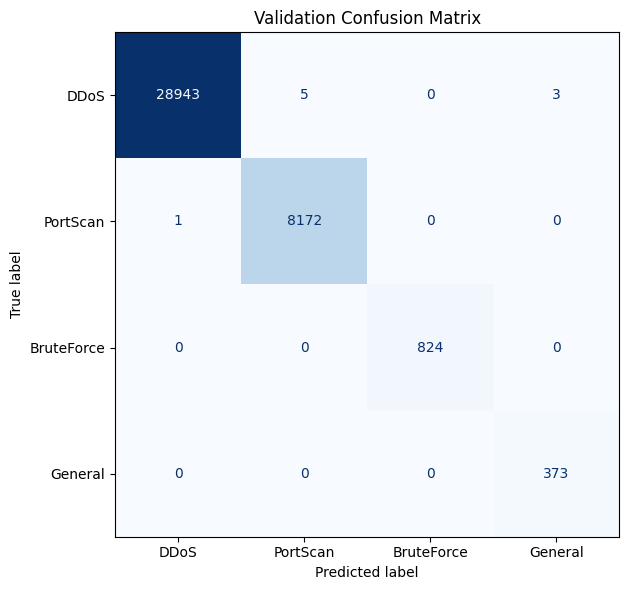

In [5]:
y_val_pred = model.predict(X_val)

print("=== Validation Report ===")
print(classification_report(
    y_val, y_val_pred,
    target_names=list(LABEL_NAMES.values())
))

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=list(LABEL_NAMES.values()))
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Validation Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/val_confusion_matrix.png", dpi=150)
plt.show()

## 5. Test Evaluation

=== Test Report ===
              precision    recall  f1-score   support

        DDoS       1.00      1.00      1.00     32177
    PortScan       1.00      1.00      1.00      9082
  BruteForce       1.00      1.00      1.00       915
     General       0.99      1.00      1.00       414

    accuracy                           1.00     42588
   macro avg       1.00      1.00      1.00     42588
weighted avg       1.00      1.00      1.00     42588

Macro F1: 0.9985


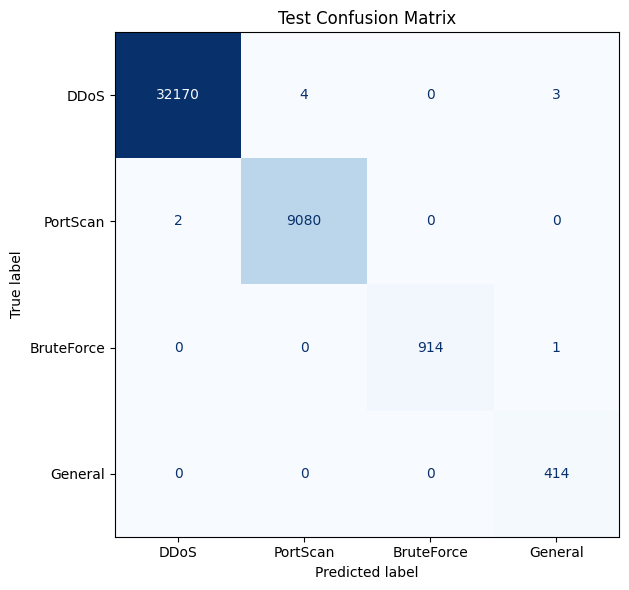

In [6]:
y_test_pred = model.predict(X_test)

print("=== Test Report ===")
print(classification_report(
    y_test, y_test_pred,
    target_names=list(LABEL_NAMES.values())
))

macro_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Macro F1: {macro_f1:.4f}")

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
disp2 = ConfusionMatrixDisplay(cm_test, display_labels=list(LABEL_NAMES.values()))
fig2, ax2 = plt.subplots(figsize=(7, 6))
disp2.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Test Confusion Matrix')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/test_confusion_matrix.png", dpi=150)
plt.show()

## 6. Feature Importance

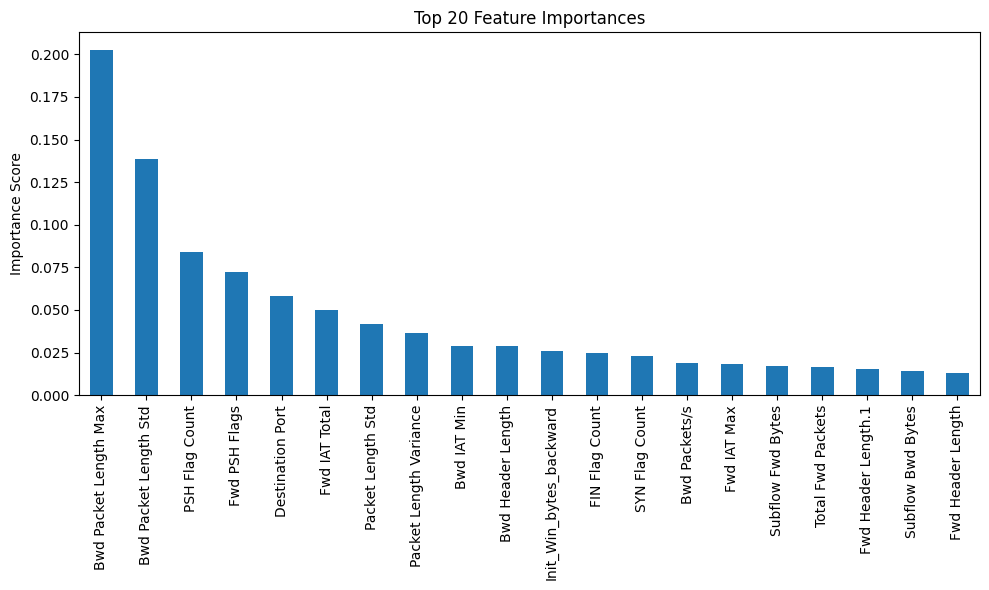


Top 10 features:
Bwd Packet Length Max     0.202810
Bwd Packet Length Std     0.138832
PSH Flag Count            0.083748
Fwd PSH Flags             0.072383
Destination Port          0.058403
Fwd IAT Total             0.049785
Packet Length Std         0.041668
Packet Length Variance    0.036679
Bwd IAT Min               0.028928
Bwd Header Length         0.028877
dtype: float32


In [7]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_n = 20
plt.figure(figsize=(10, 6))
importance.head(top_n).plot(kind='bar')
plt.title(f'Top {top_n} Feature Importances')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/feature_importance.png", dpi=150)
plt.show()

print("\nTop 10 features:")
print(importance.head(10))

## 7. Save Model

In [9]:
# Save as JSON (recommended for XGBoost)
model_save_path = f"{MODEL_PATH}/model2_xgboost.json"
model.save_model(model_save_path)
print(f"Model saved → {model_save_path}")

# Also save feature list for inference consistency
feature_cols = list(X_train.columns)
joblib.dump(feature_cols, f"{MODEL_PATH}/model2_feature_cols.pkl")
print(f"Feature list saved ({len(feature_cols)} features)")

Model saved → ../MODELS/model2_xgboost.json
Feature list saved (78 features)


## 8. Load & Inference Example

In [15]:
# How to load and use model2 from Model 1's anomaly output
loaded_model = xgb.XGBClassifier()
loaded_model.load_model(f"{MODEL_PATH}/model2_xgboost.json")

feature_cols = joblib.load(f"{MODEL_PATH}/model2_feature_cols.pkl")

LABEL_NAMES = {0: 'DDoS', 1: 'PortScan', 2: 'BruteForce', 3: 'General'}

def predict_attack_type(X_anomalies: pd.DataFrame):
    """
    Input : rows flagged as anomaly by Model 1
    Output: attack type labels
    """
    X = X_anomalies[feature_cols]
    preds = loaded_model.predict(X)           # 0-3
    labels = [LABEL_NAMES[p] for p in preds]
    proba  = loaded_model.predict_proba(X)    # confidence scores
    return preds, labels, proba

# Quick smoke test on 5 test rows
preds, labels, proba = predict_attack_type(X_test.head(5))
print("Predictions:", labels)
print("True labels:", [LABEL_NAMES[v] for v in y_test.head(5).values])

Predictions: ['DDoS', 'DDoS', 'PortScan', 'DDoS', 'DDoS']
True labels: ['DDoS', 'DDoS', 'PortScan', 'DDoS', 'DDoS']


In [16]:
# ── Generate synthetic test data from REAL dataset statistics ─────────────────
import pandas as pd
import numpy as np

SEED = 42
np.random.seed(SEED)

# Load real train data to get per-class stats
train_df = pd.read_csv("../DATASET/stage2_train_resampled.csv")

LABEL_NAMES = {1: 'DDoS', 2: 'PortScan', 3: 'BruteForce', 4: 'General'}
feature_cols = [c for c in train_df.columns if c != 'Label']

synthetic_rows = []

for label in [1, 2, 3, 4]:
    class_df = train_df[train_df['Label'] == label][feature_cols]
    means = class_df.mean()
    stds  = class_df.std().clip(lower=1e-3)   # avoid zero std

    for _ in range(4):
        # Sample from per-class Gaussian distribution
        row = np.random.normal(loc=means, scale=stds * 0.3)  # 0.3 keeps it realistic
        row = dict(zip(feature_cols, row))
        row['Label'] = label
        synthetic_rows.append(row)

syn_df = pd.DataFrame(synthetic_rows)
syn_df.to_csv("synthetic_test_data_v2.csv", index=False)
print("Saved synthetic_test_data_v2.csv")
print(syn_df['Label'].value_counts().sort_index())

Saved synthetic_test_data_v2.csv
Label
1    4
2    4
3    4
4    4
Name: count, dtype: int64


In [19]:
syn = pd.read_csv("..\DATASET\synthetic_test_data_v2.csv")
X_syn = syn.drop(columns=['Label'])
y_syn_true = syn['Label'] - 1

y_syn_pred = model.predict(X_syn)

for i, (true, pred) in enumerate(zip(y_syn_true, y_syn_pred)):
    status = "✅" if true == pred else "❌"
    print(f"Row {i+1:02d} | True: {LABEL_NAMES[true+1]:12s} | Pred: {LABEL_NAMES[pred+1]:12s} {status}")

Row 01 | True: DDoS         | Pred: DDoS         ✅
Row 02 | True: DDoS         | Pred: General      ❌
Row 03 | True: DDoS         | Pred: General      ❌
Row 04 | True: DDoS         | Pred: General      ❌
Row 05 | True: PortScan     | Pred: PortScan     ✅
Row 06 | True: PortScan     | Pred: PortScan     ✅
Row 07 | True: PortScan     | Pred: General      ❌
Row 08 | True: PortScan     | Pred: PortScan     ✅
Row 09 | True: BruteForce   | Pred: BruteForce   ✅
Row 10 | True: BruteForce   | Pred: BruteForce   ✅
Row 11 | True: BruteForce   | Pred: BruteForce   ✅
Row 12 | True: BruteForce   | Pred: BruteForce   ✅
Row 13 | True: General      | Pred: General      ✅
Row 14 | True: General      | Pred: General      ✅
Row 15 | True: General      | Pred: General      ✅
Row 16 | True: General      | Pred: General      ✅


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\sudee\AppData\Local\Temp\ipykernel_15788\608448175.py:1: SyntaxWarning: invalid escape sequence '\D'
  syn = pd.read_csv("..\DATASET\synthetic_test_data_v2.csv")
